# Telco Customer Churn — Retention & Cohort Analysis

End-to-end analysis of the IBM Telco Customer Churn dataset: data cleaning, churn/retention trends, cohort analysis, and churn-driver identification, aimed at generating retention insights for a subscription business.

**Sections**
1. Setup
2. Data Cleaning & Feature Engineering
3. Churn Rate & Retention Trends
4. Cohort Analysis
5. Churn Drivers (statistical + Random Forest)
6. Visual Summary
7. Executive Insights

> **Note on "cohorts":** this dataset has no explicit signup date or region field. Cohorts are built from `tenure` (months as a customer) as a proxy for signup era, plus contract type, spend tier, and household segment as additional cohort axes.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

# Paths (all relative to this notebook's folder — keep the CSV alongside it)
RAW_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
OUT_DIR = "outputs"
FIG_DIR = "figures"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


## 2. Data Cleaning & Feature Engineering

Fixes applied:
- `TotalCharges` is stored as text with blanks for brand-new customers (`tenure == 0`) — coerced to numeric and filled
- `"No internet service"` / `"No phone service"` collapsed into `"No"` for the add-on service columns (they mean the same thing for churn purposes)
- Engineered fields: `TenureCohort`, `NumAddOnServices`, `ARPU`, `SpendTier`, `IsMonthToMonth`, `HasSecuritySuite`


In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(df_raw.shape)
df_raw.head(3)


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- Fix TotalCharges ---
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df.loc[df["TotalCharges"].isna() & (df["tenure"] == 0), "TotalCharges"] = 0.0
    still_na = df["TotalCharges"].isna()
    df.loc[still_na, "TotalCharges"] = df.loc[still_na, "MonthlyCharges"] * df.loc[still_na, "tenure"]

    # --- Standardize churn / senior citizen flags ---
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)
    df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)

    # --- Collapse "No internet/phone service" into "No" ---
    service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                     "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]
    for col in service_cols:
        df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

    # --- Feature engineering ---
    bins = [-1, 6, 12, 24, 36, 48, 60, 72]
    labels = ["0-6mo", "7-12mo", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5-6yr"]
    df["TenureCohort"] = pd.cut(df["tenure"], bins=bins, labels=labels)

    df["NumAddOnServices"] = (df[service_cols[:-1]] == "Yes").sum(axis=1)  # excludes MultipleLines (phone, not internet add-on)

    df["ARPU"] = np.where(df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"])
    df["SpendTier"] = pd.qcut(df["MonthlyCharges"], q=3, labels=["Low", "Medium", "High"])
    df["IsMonthToMonth"] = (df["Contract"] == "Month-to-month").astype(int)
    df["HasSecuritySuite"] = ((df["OnlineSecurity"] == "Yes") | (df["TechSupport"] == "Yes")).astype(int)

    return df

df = clean(df_raw)
df.to_csv(f"{OUT_DIR}/../{OUT_DIR}" if False else f"clean_churn.csv", index=False)  # local copy for convenience
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"Overall churn rate: {df['Churn'].mean():.2%}")
df.head(3)


Rows: 7043, Columns: 27
Overall churn rate: 26.54%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCohort,NumAddOnServices,ARPU,SpendTier,IsMonthToMonth,HasSecuritySuite
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6mo,1,29.850000,Low,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-3yr,2,55.573529,Medium,0,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6mo,2,54.075000,Medium,1,1


## 3. Churn Rate & Retention Trends

Overall churn rate, churn by tenure (retention curve), and churn by contract / payment method / internet service.


In [4]:
overall_churn = df["Churn"].mean()
print(f"Overall churn rate: {overall_churn:.2%}  ({df['Churn'].sum()} of {len(df)} customers)")


Overall churn rate: 26.54%  (1869 of 7043 customers)


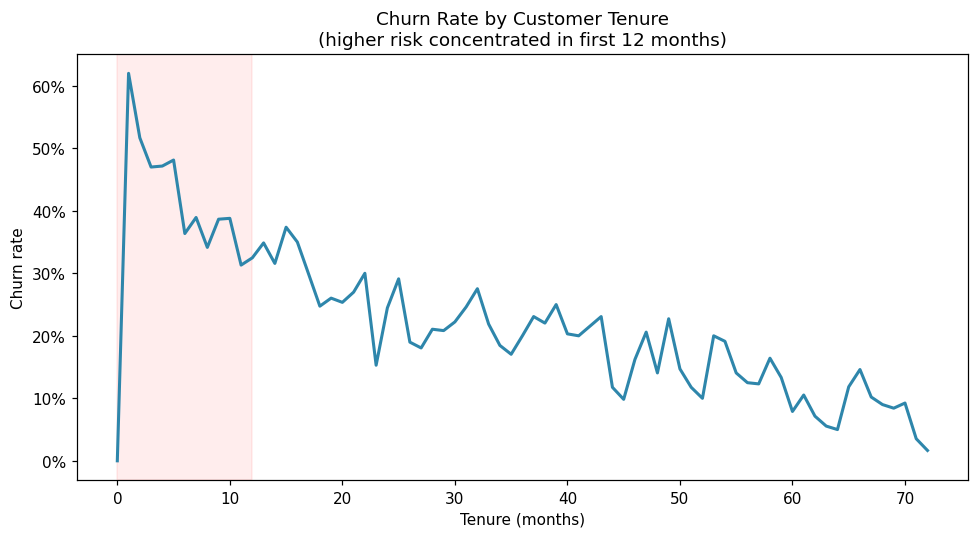

In [5]:
# Churn rate by tenure month (retention curve)
tenure_churn = df.groupby("tenure")["Churn"].agg(["mean", "count"]).reset_index()
tenure_churn.columns = ["tenure_months", "churn_rate", "n_customers"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tenure_churn["tenure_months"], tenure_churn["churn_rate"], color="#2E86AB", lw=2)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churn rate")
ax.set_title("Churn Rate by Customer Tenure\n(higher risk concentrated in first 12 months)")
ax.axvspan(0, 12, color="red", alpha=0.07)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/churn_by_tenure.png")
plt.show()

tenure_churn.to_csv(f"{OUT_DIR}/churn_by_tenure.csv", index=False)


                churn_rate  n_customers
Contract                               
Month-to-month    0.427097         3875
One year          0.112695         1473
Two year          0.028319         1695


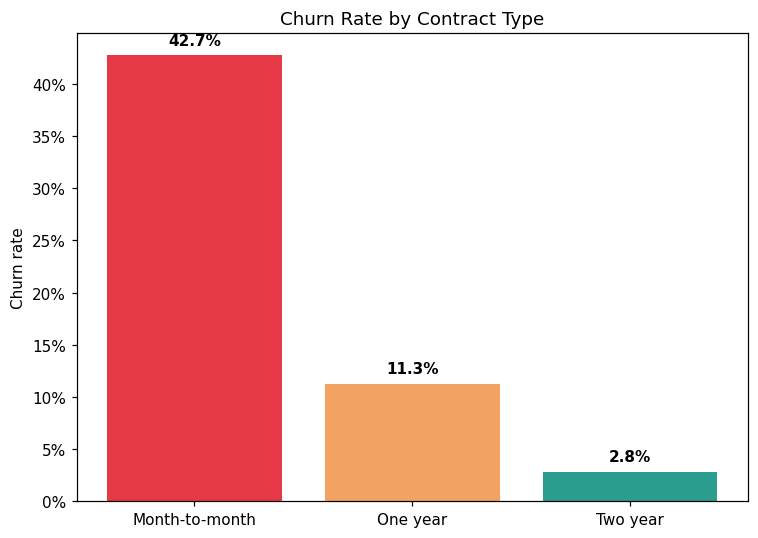

In [6]:
# Churn rate by contract type
contract_churn = df.groupby("Contract")["Churn"].agg(["mean", "count"]).sort_values("mean", ascending=False)
contract_churn.columns = ["churn_rate", "n_customers"]
print(contract_churn)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(contract_churn.index, contract_churn["churn_rate"], color=["#E63946", "#F4A261", "#2A9D8F"])
ax.set_ylabel("Churn rate")
ax.set_title("Churn Rate by Contract Type")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for bar, rate in zip(bars, contract_churn["churn_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.01, f"{rate:.1%}", ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/churn_by_contract.png")
plt.show()

contract_churn.to_csv(f"{OUT_DIR}/churn_by_contract.csv")


In [7]:
# Churn rate by payment method
payment_churn = df.groupby("PaymentMethod")["Churn"].agg(["mean", "count"]).sort_values("mean", ascending=False)
payment_churn.columns = ["churn_rate", "n_customers"]
payment_churn.to_csv(f"{OUT_DIR}/churn_by_payment.csv")
payment_churn


,churn_rate,n_customers
PaymentMethod,,
Electronic check,0.452854,2365
Mailed check,0.191067,1612
Bank transfer (automatic),0.167098,1544
Credit card (automatic),0.152431,1522


In [8]:
# Churn rate by internet service type
internet_churn = df.groupby("InternetService")["Churn"].agg(["mean", "count"]).sort_values("mean", ascending=False)
internet_churn.columns = ["churn_rate", "n_customers"]
internet_churn.to_csv(f"{OUT_DIR}/churn_by_internet.csv")
internet_churn


,churn_rate,n_customers
InternetService,,
Fiber optic,0.418928,3096
DSL,0.189591,2421
No,0.074050,1526


## 4. Cohort Analysis

Cohorts by tenure bucket (signup-era proxy), contract/plan, spend tier, and household segment — each with churn rate, average spend, and share of base.


In [9]:
def cohort_summary(df, group_col):
    g = df.groupby(group_col, observed=True).agg(
        n_customers=("customerID", "count"),
        churn_rate=("Churn", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean"),
        avg_total_charges=("TotalCharges", "mean"),
        avg_tenure=("tenure", "mean"),
    ).round(2)
    g["pct_of_base"] = (g["n_customers"] / len(df) * 100).round(1)
    return g.sort_values("churn_rate", ascending=False)


In [10]:
tenure_cohort = cohort_summary(df, "TenureCohort")
tenure_cohort.to_csv(f"{OUT_DIR}/cohort_by_tenure_bucket.csv")
tenure_cohort


,n_customers,churn_rate,avg_monthly_charges,avg_total_charges,avg_tenure,pct_of_base
TenureCohort,,,,,,
0-6mo,1481,0.53,54.74,142.57,2.51,21.0
7-12mo,705,0.36,58.95,553.91,9.40,10.0
1-2yr,1024,0.29,61.36,1126.26,18.35,14.5
2-3yr,832,0.22,65.58,1990.20,30.34,11.8
3-4yr,762,0.19,66.32,2827.47,42.58,10.8
4-5yr,832,0.14,70.55,3848.13,54.49,11.8
5-6yr,1407,0.07,75.95,5180.67,68.11,20.0


In [11]:
contract_cohort = cohort_summary(df, "Contract")
contract_cohort.to_csv(f"{OUT_DIR}/cohort_by_contract.csv")
contract_cohort


,n_customers,churn_rate,avg_monthly_charges,avg_total_charges,avg_tenure,pct_of_base
Contract,,,,,,
Month-to-month,3875,0.43,66.40,1369.25,18.04,55.0
One year,1473,0.11,65.05,3032.62,42.04,20.9
Two year,1695,0.03,60.77,3706.93,56.74,24.1


In [12]:
internet_cohort = cohort_summary(df, "InternetService")
internet_cohort.to_csv(f"{OUT_DIR}/cohort_by_internet_plan.csv")
internet_cohort


,n_customers,churn_rate,avg_monthly_charges,avg_total_charges,avg_tenure,pct_of_base
InternetService,,,,,,
Fiber optic,3096,0.42,91.50,3205.30,32.92,44.0
DSL,2421,0.19,58.10,2115.41,32.82,34.4
No,1526,0.07,21.08,662.60,30.55,21.7


In [13]:
spend_cohort = cohort_summary(df, "SpendTier")
spend_cohort.to_csv(f"{OUT_DIR}/cohort_by_spend_tier.csv")
spend_cohort


,n_customers,churn_rate,avg_monthly_charges,avg_total_charges,avg_tenure,pct_of_base
SpendTier,,,,,,
High,2347,0.34,97.33,4171.53,42.03,33.3
Medium,2345,0.30,69.04,1954.69,28.37,33.3
Low,2351,0.16,27.99,715.37,26.72,33.4


In [14]:
# Cross-tab: are new month-to-month customers the riskiest segment?
cross = df.pivot_table(index="TenureCohort", columns="Contract", values="Churn",
                        aggfunc="mean", observed=True).round(3)
cross.to_csv(f"{OUT_DIR}/cohort_tenure_x_contract.csv")
cross


Contract,Month-to-month,One year,Two year
TenureCohort,,,
0-6mo,0.552,0.103,0.000
7-12mo,0.420,0.106,0.000
1-2yr,0.377,0.081,0.000
2-3yr,0.325,0.080,0.021
3-4yr,0.335,0.131,0.022
4-5yr,0.278,0.137,0.040
5-6yr,0.222,0.121,0.031


In [15]:
df["HouseholdSegment"] = df["Partner"] + "_Partner_" + df["Dependents"] + "_Dependents"
household_cohort = cohort_summary(df, "HouseholdSegment")
household_cohort.to_csv(f"{OUT_DIR}/cohort_by_household.csv")
household_cohort


,n_customers,churn_rate,avg_monthly_charges,avg_total_charges,avg_tenure,pct_of_base
HouseholdSegment,,,,,,
No_Partner_No_Dependents,3280,0.34,62.98,1610.70,23.30,46.6
Yes_Partner_No_Dependents,1653,0.25,74.98,3332.65,42.71,23.5
No_Partner_Yes_Dependents,361,0.21,52.51,1342.29,23.85,5.1
Yes_Partner_Yes_Dependents,1749,0.14,60.97,2732.78,41.36,24.8


## 5. Churn Drivers

Two complementary views:
1. **Univariate lift** — for each categorical feature, how much higher/lower is churn vs. the base rate (business-readable)
2. **Random Forest feature importance** — captures nonlinear effects and interactions between features

Plus a concrete **revenue-at-risk** calculation for a defined high-risk segment.


In [16]:
overall_rate = df["Churn"].mean()

driver_cols = [
    "Contract", "PaymentMethod", "InternetService", "OnlineSecurity",
    "TechSupport", "OnlineBackup", "DeviceProtection", "StreamingTV",
    "StreamingMovies", "PaperlessBilling", "SeniorCitizen", "Partner",
    "Dependents", "gender", "MultipleLines",
]

rows = []
for col in driver_cols:
    grp = df.groupby(col)["Churn"].agg(["mean", "count"])
    for level, r in grp.iterrows():
        lift = (r["mean"] - overall_rate) / overall_rate * 100
        rows.append({
            "driver": col,
            "level": level,
            "churn_rate": round(r["mean"], 4),
            "n_customers": int(r["count"]),
            "lift_vs_avg_pct": round(lift, 1),
        })

lift_df = pd.DataFrame(rows).sort_values("lift_vs_avg_pct", ascending=False)
lift_df.to_csv(f"{OUT_DIR}/driver_lift_analysis.csv", index=False)

print("Top 10 churn-INCREASING factors:")
display(lift_df.head(10))
print("\nTop 10 churn-REDUCING factors:")
display(lift_df.tail(10).sort_values("lift_vs_avg_pct"))


Top 10 churn-INCREASING factors:


,driver,level,churn_rate,n_customers,lift_vs_avg_pct
5,PaymentMethod,Electronic check,0.4529,2365,70.7
0,Contract,Month-to-month,0.4271,3875,60.9
8,InternetService,Fiber optic,0.4189,3096,57.9
25,SeniorCitizen,1,0.4168,1142,57.1
23,PaperlessBilling,Yes,0.3357,4171,26.5
26,Partner,No,0.3296,3641,24.2
10,OnlineSecurity,No,0.3133,5024,18.1
28,Dependents,No,0.3128,4933,17.9
12,TechSupport,No,0.3119,4999,17.5
19,StreamingTV,Yes,0.3007,2707,13.3



Top 10 churn-REDUCING factors:


,driver,level,churn_rate,n_customers,lift_vs_avg_pct
2,Contract,Two year,0.0283,1695,-89.3
9,InternetService,No,0.0740,1526,-72.1
1,Contract,One year,0.1127,1473,-57.5
11,OnlineSecurity,Yes,0.1461,2019,-44.9
13,TechSupport,Yes,0.1517,2044,-42.8
4,PaymentMethod,Credit card (automatic),0.1524,1522,-42.6
29,Dependents,Yes,0.1545,2110,-41.8
22,PaperlessBilling,No,0.1633,2872,-38.5
3,PaymentMethod,Bank transfer (automatic),0.1671,1544,-37.0
7,InternetService,DSL,0.1896,2421,-28.6


In [17]:
# Random Forest model for nonlinear / interaction-aware feature importance
model_df = df.drop(columns=["customerID", "TenureCohort", "SpendTier", "ARPU", "HouseholdSegment"])
cat_cols = model_df.select_dtypes(include="object").columns.tolist()

encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    model_df[c] = le.fit_transform(model_df[c])
    encoders[c] = le

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f"Random Forest churn-prediction model AUC: {auc:.3f}\n")
print(classification_report(y_test, rf.predict(X_test), target_names=["Retained", "Churned"]))

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.to_csv(f"{OUT_DIR}/rf_feature_importance.csv", header=["importance"])

print("\nTop 10 predictive drivers:")
importances.head(10).round(4)


/tmp/ipykernel_117/3517184554.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include="object").columns.tolist()


Random Forest churn-prediction model AUC: 0.846

              precision    recall  f1-score   support

    Retained       0.91      0.74      0.82      1294
     Churned       0.53      0.79      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.77      1761


Top 10 predictive drivers:


IsMonthToMonth      0.2019
Contract            0.1798
tenure              0.1331
MonthlyCharges      0.1132
InternetService     0.0917
TotalCharges        0.0767
HasSecuritySuite    0.0313
PaymentMethod       0.0310
PaperlessBilling    0.0277
NumAddOnServices    0.0190
dtype: float64

In [18]:
# Revenue at risk: concrete high-risk segment
df["ChurnRiskFlag"] = (
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12) &
    (df["OnlineSecurity"] == "No") &
    (df["TechSupport"] == "No")
).astype(int)

at_risk = df[df["ChurnRiskFlag"] == 1]

print("High-risk segment: Month-to-month + tenure<=12mo + no OnlineSecurity + no TechSupport")
print(f"Customers: {len(at_risk)} ({len(at_risk)/len(df):.1%} of base)")
print(f"Their churn rate: {at_risk['Churn'].mean():.1%}  (vs base {overall_rate:.1%})")
print(f"Monthly revenue exposure: ${at_risk['MonthlyCharges'].sum():,.0f}/mo")
print(f"Annualized revenue exposure: ${at_risk['MonthlyCharges'].sum()*12:,.0f}/yr")

with open(f"{OUT_DIR}/high_risk_segment_summary.txt", "w") as f:
    f.write("High-risk segment: Month-to-month + tenure<=12mo + no OnlineSecurity + no TechSupport\n")
    f.write(f"Customers: {len(at_risk)} ({len(at_risk)/len(df):.1%} of base)\n")
    f.write(f"Churn rate: {at_risk['Churn'].mean():.1%} vs base {overall_rate:.1%}\n")
    f.write(f"Monthly revenue exposure: ${at_risk['MonthlyCharges'].sum():,.0f}\n")
    f.write(f"Annualized revenue exposure: ${at_risk['MonthlyCharges'].sum()*12:,.0f}\n")


High-risk segment: Month-to-month + tenure<=12mo + no OnlineSecurity + no TechSupport
Customers: 1576 (22.4% of base)
Their churn rate: 54.2%  (vs base 26.5%)
Monthly revenue exposure: $88,603/mo
Annualized revenue exposure: $1,063,239/yr


## 6. Visual Summary

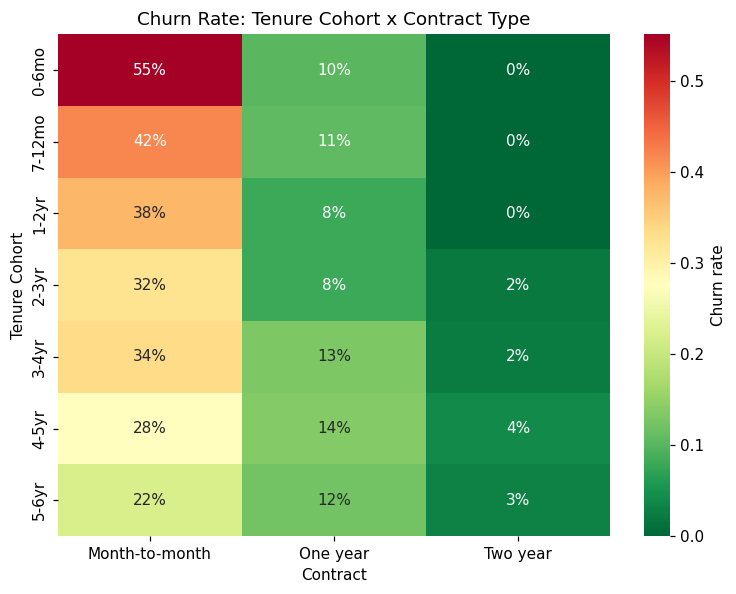

In [19]:
# Cohort heatmap: tenure bucket x contract churn rate
order = ["0-6mo", "7-12mo", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5-6yr"]
cross_plot = cross.reindex(order)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cross_plot, annot=True, fmt=".0%", cmap="RdYlGn_r", ax=ax, cbar_kws={"label": "Churn rate"})
ax.set_title("Churn Rate: Tenure Cohort x Contract Type")
ax.set_ylabel("Tenure Cohort")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/cohort_heatmap.png")
plt.show()


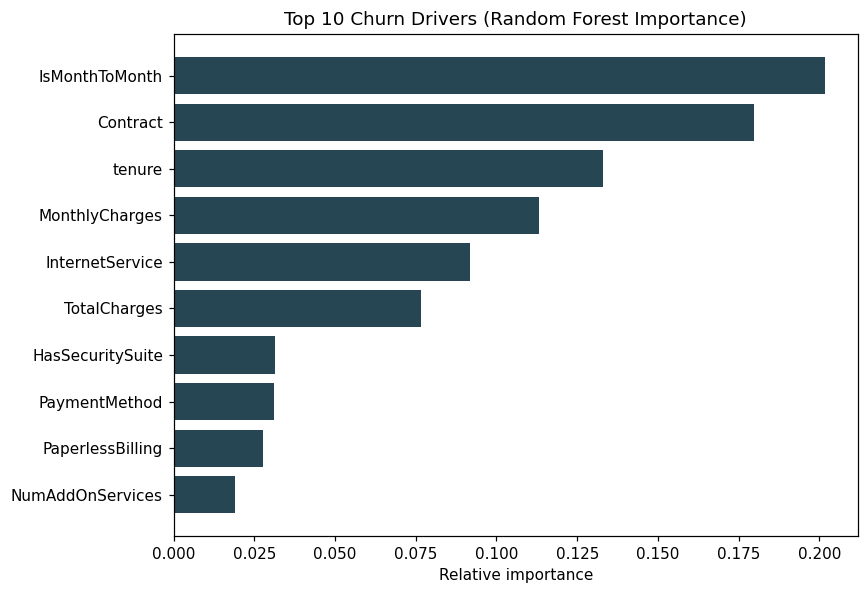

In [20]:
# Feature importance bar chart
imp = importances.head(10)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(imp.index[::-1], imp.values[::-1], color="#264653")
ax.set_xlabel("Relative importance")
ax.set_title("Top 10 Churn Drivers (Random Forest Importance)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/feature_importance.png")
plt.show()


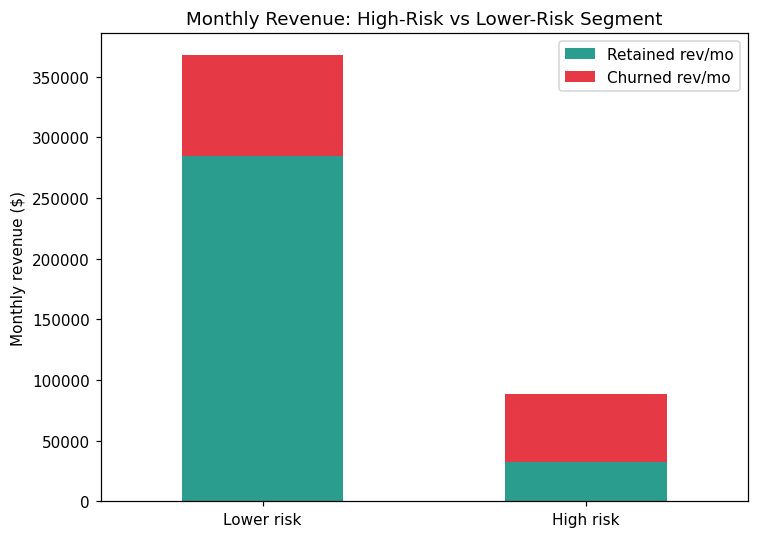

In [21]:
# Monthly revenue at risk by segment
revenue_by_group = df.groupby(["ChurnRiskFlag", "Churn"])["MonthlyCharges"].sum().unstack()
revenue_by_group.index = ["Lower risk", "High risk"]
revenue_by_group.columns = ["Retained rev/mo", "Churned rev/mo"]

fig, ax = plt.subplots(figsize=(7, 5))
revenue_by_group.plot(kind="bar", stacked=True, ax=ax, color=["#2A9D8F", "#E63946"])
ax.set_ylabel("Monthly revenue ($)")
ax.set_title("Monthly Revenue: High-Risk vs Lower-Risk Segment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/revenue_at_risk.png")
plt.show()


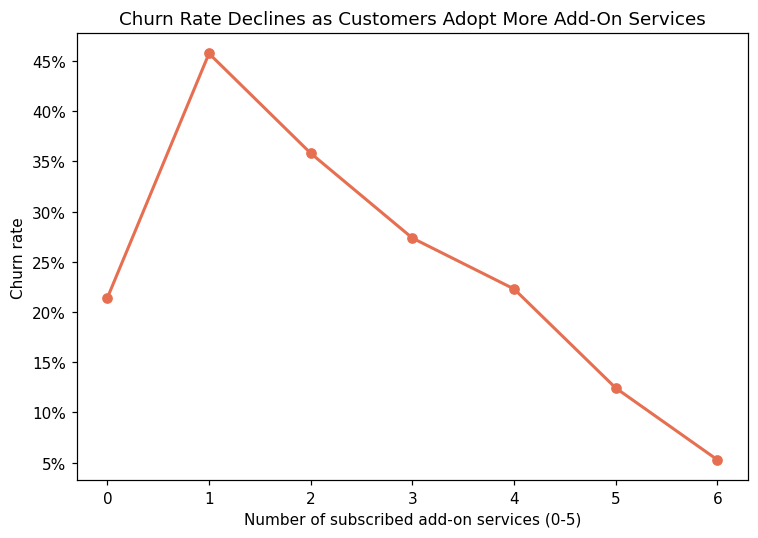

In [22]:
# Add-on service count vs churn (stickiness effect)
addon_churn = df.groupby("NumAddOnServices")["Churn"].mean()
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(addon_churn.index, addon_churn.values, marker="o", color="#E76F51", lw=2)
ax.set_xlabel("Number of subscribed add-on services (0-5)")
ax.set_ylabel("Churn rate")
ax.set_title("Churn Rate Declines as Customers Adopt More Add-On Services")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/addon_stickiness.png")
plt.show()


## 7. Executive Insights

**Overall churn: 26.5%** (1,869 of 7,043 customers) — high for a subscription business.

1. **Contract type is the single biggest lever.** Month-to-month customers churn at 42.7% vs. 11.3% (1-year) and 2.8% (2-year). Confirmed as the top predictive feature by the Random Forest.
2. **Risk is front-loaded in the first year**, and specifically concentrated in *new month-to-month* customers (55% churn in months 0–6) — annual-contract customers barely churn even when new.
3. **Fiber optic customers churn 2x more than DSL** (41.9% vs 19.0%) — worth investigating service quality, pricing, or competitive pressure.
4. **Electronic check payers churn at 45.3%**, vs ~15–19% for automatic payment methods — friction at renewal is a strong signal.
5. **Add-on services create stickiness** — churn drops monotonically as customers adopt more services (Online Security, Tech Support, etc.).
6. **Concrete risk segment:** month-to-month + tenure ≤12mo + no security/support add-ons = ~22% of the base churning at ~54%, representing roughly **$1M+/year in exposed revenue**.

### Recommended retention actions
1. Incentivize contract upgrades (discount for 1–2yr commitment) — biggest single lever
2. Push auto-pay enrollment for electronic-check customers
3. Bundle Online Security / Tech Support into the first 90 days free
4. Investigate Fiber optic churn root cause (pricing vs. service quality)
5. Build a "first 6 months" onboarding/retention program for month-to-month signups
